# Análisis Exploratorio de Datos (EDA) - Rendimiento de Hospitales en Pakistán

Este notebook realiza un análisis exhaustivo de los datos de rendimiento hospitalario, incluyendo visualizaciones, análisis estadístico, métodos de machine learning y pruebas de hipótesis.

In [22]:
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
query = "SELECT * FROM hospital_performance_final"

df = pd.read_sql(query, engine)
df.head()

,hospital_id,hospital_name,sector,city,province,hospital_type,year,total_beds,icu_beds,operation_theatres,emergency_department,diagnostic_labs,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,insurance_accepted,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,ambulance_available,telemedicine_service,rural_patients_percentage,icu_inconsistency_flag,icu_high_ratio_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,estimated_daily_load,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,performance_category
0,H10000,Hospital_TSDGA,Public,Sialkot,Punjab,Specialized,2024,1432,49,6,Yes,No,5.3,331,120,799,269,0.001418,2367,775,260,3.2,692,976,621,39060,29429077,Yes,5.1,2.24,3.34,8.49,31,8.2,Yes,No,49.0,0,0,0,0,43,2392.833333,1399,0,0.342,0.826,0.990,0.617,Medium Performance
1,H10001,Hospital_VAXQQ,Private,Quetta,Balochistan,General,2023,905,29,4,No,No,8.5,271,36,381,38,0.001547,642,1488,101,3.7,61,3614,2516,31821,0,Yes,7.3,0.66,6.70,7.76,5,29.1,No,Yes,15.0,0,0,0,0,25,691.600000,690,1,0.443,0.871,0.937,0.670,Medium Performance
2,H10002,Hospital_XABQD,Public,Kasur,Punjab,Specialized,2024,456,141,20,Yes,Yes,6.8,135,90,83,212,0.000927,992,928,331,4.6,16,6865,252,45706,38516209,No,7.9,4.71,4.07,7.39,179,3.7,Yes,No,68.0,0,0,0,0,16,1022.933333,430,0,0.362,0.321,0.871,0.452,Low Performance
3,H10003,Hospital_AYNGM,Public,Sheikhupura,Punjab,Specialized,2023,890,121,1,No,Yes,7.5,216,101,115,253,0.001625,921,170,162,4.7,257,12006,276,75900,35923243,No,7.5,3.95,5.32,9.41,116,39.1,Yes,Yes,45.0,0,0,0,0,162,926.666667,584,0,0.278,0.495,0.767,0.441,Low Performance
4,H10004,Hospital_ZRAVI,Public,Sheikhupura,Punjab,Specialized,2022,978,72,17,Yes,Yes,7.4,381,43,474,65,0.000704,1555,591,283,7.7,690,875,530,73349,32512196,Yes,9.1,4.88,0.96,3.15,99,18.4,Yes,No,15.0,0,0,0,0,16,1574.700000,920,0,0.657,0.367,0.992,0.637,Medium Performance


In [25]:
# Mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5274 entries, 0 to 5273
Data columns (total 50 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   hospital_id                 5274 non-null   object 
 1   hospital_name               5274 non-null   object 
 2   sector                      5274 non-null   object 
 3   city                        5274 non-null   object 
 4   province                    5274 non-null   object 
 5   hospital_type               5274 non-null   object 
 6   year                        5274 non-null   int64  
 7   total_beds                  5274 non-null   int64  
 8   icu_beds                    5274 non-null   int64  
 9   operation_theatres          5274 non-null   int64  
 10  emergency_department        5274 non-null   object 
 11  diagnostic_labs             5274 non-null   object 
 12  medical_equipment_score     5274 non-null   float64
 13  total_doctors               5274 

In [27]:
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, LabelEncoder

## Análisis Descriptivo

In [28]:
# Estadísticas descriptivas
df.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,icu_inconsistency_flag,icu_high_ratio_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,estimated_daily_load,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi
count,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.00000,5274.000000,5274.000000,5274.000000,5274.000000,5.274000e+03,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.0,5274.00000,5274.00000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000,5274.000000
mean,2022.989951,807.114524,101.028821,10.586272,6.497801,204.091392,78.215207,405.879977,153.102958,0.001253,1513.180508,754.631968,203.791619,5.70584,407.704589,16929.227911,1588.904058,100408.902920,1.260734e+07,7.302901,2.758699,3.806456,5.460535,92.961320,20.467368,42.952218,0.0,0.00019,0.00019,0.093667,35.553091,1538.334907,763.074327,0.650550,0.501382,0.501289,0.667889,0.534650
std,0.823335,406.128826,56.756051,5.768386,1.434765,113.219005,42.204969,226.280186,85.017865,0.000434,844.664082,425.849164,114.784056,2.48163,229.512034,13640.698131,1478.887847,82370.540702,1.605290e+07,1.298841,1.309645,1.886987,2.610138,50.388982,11.306001,21.731967,0.0,0.01377,0.01377,0.484097,53.071449,844.759949,265.852492,1.938117,0.146327,0.206341,0.275791,0.109792
min,2022.000000,51.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000500,50.000000,21.000000,5.000000,1.50000,10.000000,502.000000,100.000000,5065.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.000000,0.0,0.00000,0.00000,0.000000,0.000000,57.400000,82.000000,0.000000,0.069000,0.003000,0.000000,0.179000
25%,2022.000000,448.000000,52.000000,6.000000,5.300000,107.000000,41.000000,213.000000,78.000000,0.000881,790.000000,392.000000,105.250000,3.50000,209.000000,6627.250000,441.250000,38817.750000,0.000000e+00,6.200000,1.610000,2.160000,3.170000,51.000000,10.400000,25.000000,0.0,0.00000,0.00000,0.000000,9.000000,813.058333,565.000000,0.000000,0.401000,0.353000,0.480000,0.459000
50%,2023.000000,811.000000,100.500000,11.000000,6.500000,204.000000,79.000000,403.000000,152.000000,0.001255,1521.500000,748.000000,206.000000,5.70000,409.000000,11996.000000,754.000000,67373.000000,1.628446e+06,7.300000,2.770000,3.870000,5.430000,93.000000,20.650000,43.000000,0.0,0.00000,0.00000,0.000000,19.000000,1548.100000,762.000000,0.000000,0.498000,0.503000,0.768000,0.537000
75%,2024.000000,1160.750000,149.000000,16.000000,7.700000,302.000000,115.000000,601.000000,228.000000,0.001635,2233.000000,1124.000000,305.000000,7.80000,608.000000,26234.500000,2724.750000,155740.250000,2.470596e+07,8.400000,3.910000,5.440000,7.730000,136.000000,30.200000,62.000000,0.0,0.00000,0.00000,0.000000,37.000000,2260.491667,965.000000,0.000000,0.604000,0.650000,0.876000,0.613000
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,3000.000000,1500.000000,400.000000,10.00000,800.000000,49964.000000,4995.000000,299953.000000,4.998359e+07,9.500000,5.000000,7.000000,10.000000,180.000000,40.000000,80.000000,0.0,1.00000,1.00000,7.000000,399.000000,3042.900000,1474.000000,22.000000,0.954000,0.997000,1.000000,0.877000


In [29]:
# Distribución por sector
print("Distribución por sector:")
print(df['sector'].value_counts())

# Distribución por provincia
print("\nDistribución por provincia:")
print(df['province'].value_counts())

# Distribución por tipo de hospital
print("\nDistribución por tipo de hospital:")
print(df['hospital_type'].value_counts())

# Distribución por categoría de rendimiento
print("\nDistribución por categoría de rendimiento:")
print(df['performance_category'].value_counts())

Distribución por sector:
sector
Public     2673
Private    2601
Name: count, dtype: int64

Distribución por provincia:
province
Punjab                         2839
Sindh                          1065
Khyber Pakhtunkhwa              828
Islamabad Capital Territory     283
Balochistan                     259
Name: count, dtype: int64

Distribución por tipo de hospital:
hospital_type
Specialized    1785
Teaching       1754
General        1735
Name: count, dtype: int64

Distribución por categoría de rendimiento:
performance_category
Medium Performance    3221
Low Performance       1955
High Performance        98
Name: count, dtype: int64


## Visualizaciones

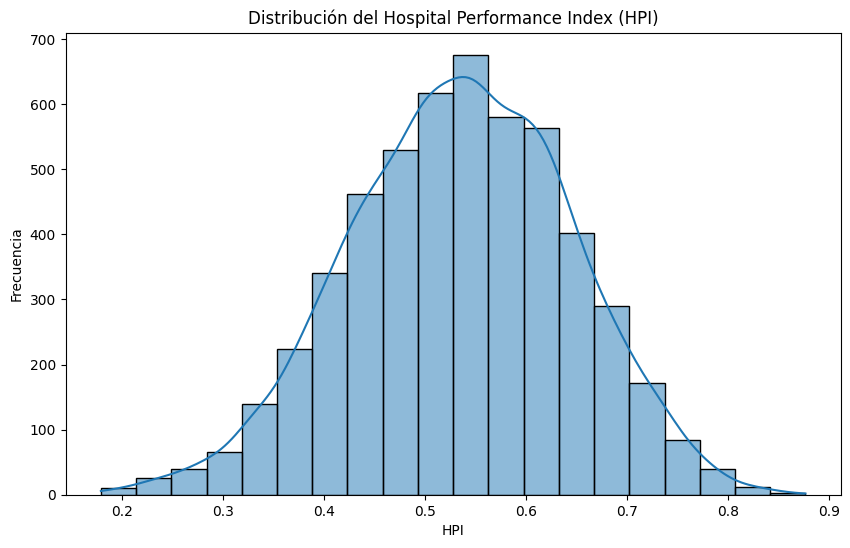

In [30]:
# Histograma del HPI
plt.figure(figsize=(10, 6))
sns.histplot(df['hpi'], bins=20, kde=True)
plt.title('Distribución del Hospital Performance Index (HPI)')
plt.xlabel('HPI')
plt.ylabel('Frecuencia')
plt.show()

C:\Users\Estudio\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\seaborn\categorical.py:632: FutureWarning: SeriesGroupBy.grouper is deprecated and will be removed in a future version of pandas.
  positions = grouped.grouper.result_index.to_numpy(dtype=float)


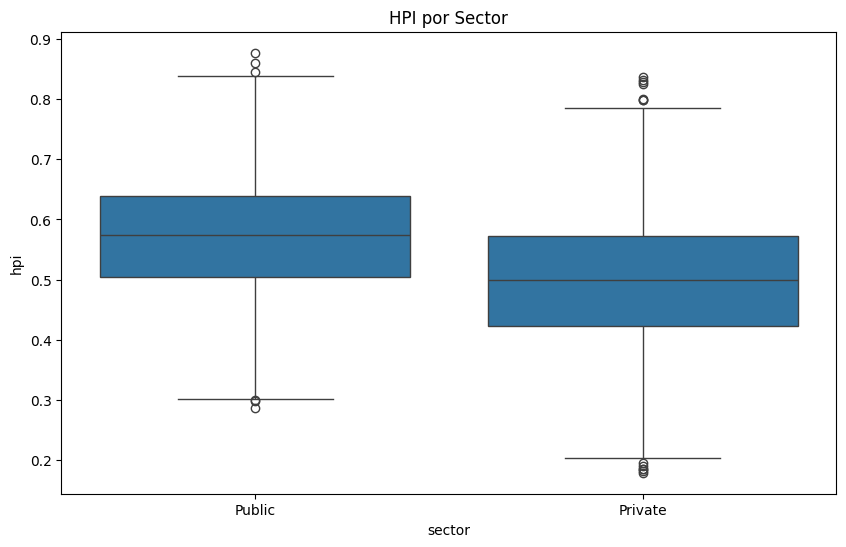

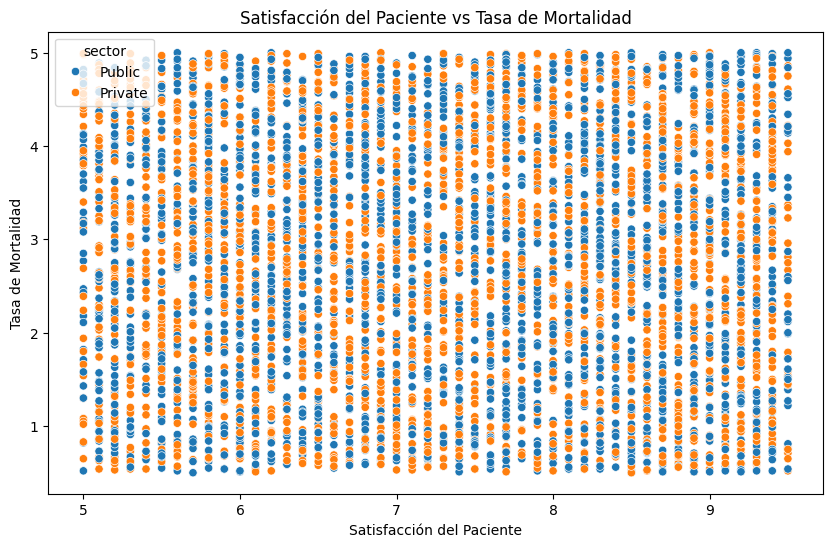

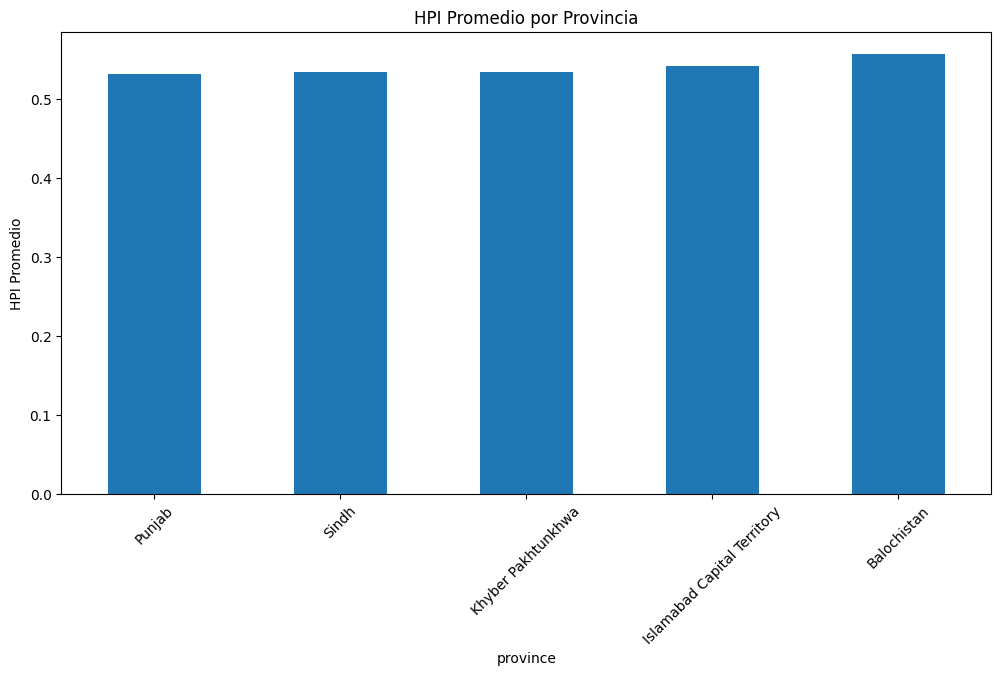

In [31]:
# Boxplot del HPI por sector
plt.figure(figsize=(10, 6))
sns.boxplot(x='sector', y='hpi', data=df)
plt.title('HPI por Sector')
plt.show()

# Scatter plot: Satisfacción vs Mortalidad
plt.figure(figsize=(10, 6))
sns.scatterplot(x='patient_satisfaction_score', y='mortality_rate', data=df, hue='sector')
plt.title('Satisfacción del Paciente vs Tasa de Mortalidad')
plt.xlabel('Satisfacción del Paciente')
plt.ylabel('Tasa de Mortalidad')
plt.show()

# Gráfico de barras: Rendimiento por provincia
plt.figure(figsize=(12, 6))
province_performance = df.groupby('province')['hpi'].mean().sort_values()
province_performance.plot(kind='bar')
plt.title('HPI Promedio por Provincia')
plt.ylabel('HPI Promedio')
plt.xticks(rotation=45)
plt.show()

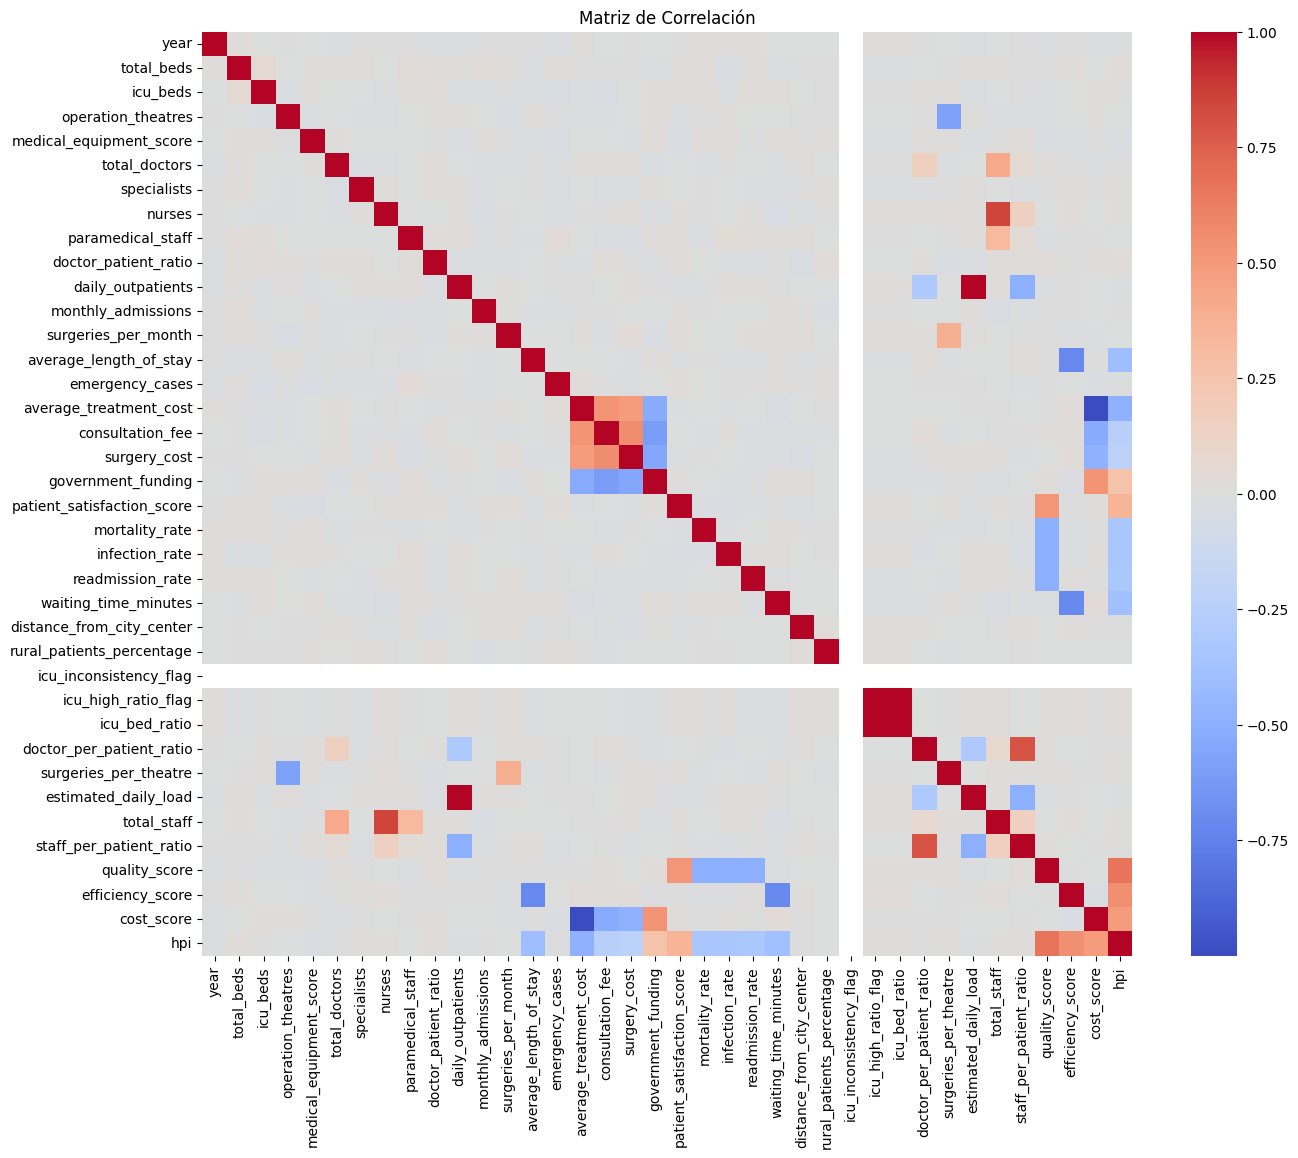

Correlaciones con HPI:
hpi                           1.000000
quality_score                 0.667167
efficiency_score              0.552840
cost_score                    0.485132
patient_satisfaction_score    0.354727
government_funding            0.265226
doctor_patient_ratio          0.022364
icu_high_ratio_flag           0.020491
icu_bed_ratio                 0.020491
total_beds                    0.015668
surgeries_per_theatre         0.013762
staff_per_patient_ratio       0.013564
nurses                        0.012864
specialists                   0.011144
total_staff                   0.009780
doctor_per_patient_ratio      0.005908
distance_from_city_center     0.004026
monthly_admissions            0.003951
total_doctors                 0.001914
icu_beds                      0.000168
rural_patients_percentage    -0.004649
surgeries_per_month          -0.005090
operation_theatres           -0.005774
paramedical_staff            -0.006202
estimated_daily_load         -0.008555
da

In [32]:
# Matriz de correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación')
plt.show()

# Correlaciones con HPI
hpi_corr = corr_matrix['hpi'].sort_values(ascending=False)
print("Correlaciones con HPI:")
print(hpi_corr)

## Métodos de Machine Learning

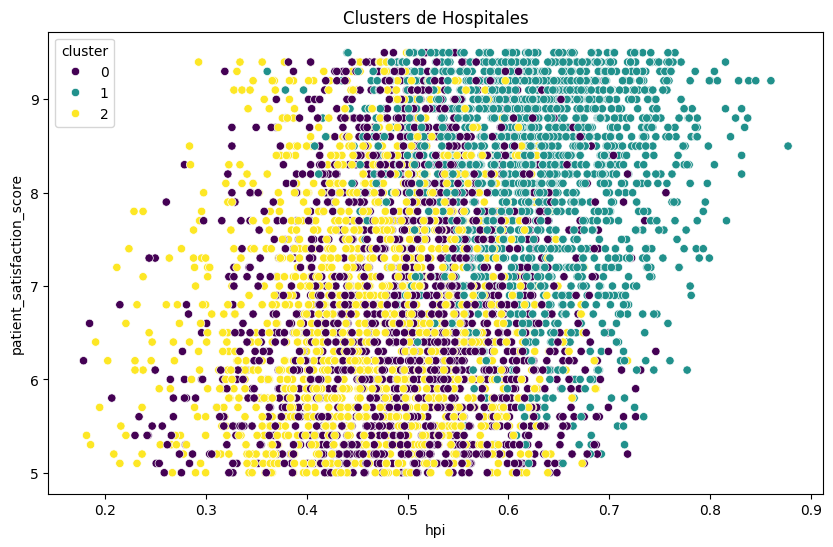

Centros de los clusters:
    total_beds  total_doctors      nurses  patient_satisfaction_score  \
0   407.044963     193.506545  407.992601                    6.849687   
1   896.380022     207.705212  407.909881                    8.231705   
2  1128.604179     211.220299  401.431642                    6.756896   

   mortality_rate       hpi  
0        2.914047  0.501417  
1        1.942378  0.626863  
2        3.493457  0.468103  


In [33]:
# Clustering con K-Means
features_for_clustering = ['total_beds', 'total_doctors', 'nurses', 'patient_satisfaction_score', 'mortality_rate', 'hpi']
X_cluster = df[features_for_clustering].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df_cluster = df.loc[X_cluster.index].copy()
df_cluster['cluster'] = clusters

# Visualizar clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='hpi', y='patient_satisfaction_score', hue='cluster', data=df_cluster, palette='viridis')
plt.title('Clusters de Hospitales')
plt.show()

print("Centros de los clusters:")
print(pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), columns=features_for_clustering))

In [34]:
# Regresión Lineal para predecir HPI
features_for_regression = ['total_beds', 'total_doctors', 'nurses', 'patient_satisfaction_score', 'mortality_rate', 'waiting_time_minutes']
X_reg = df[features_for_regression].dropna()
y_reg = df.loc[X_reg.index, 'hpi']

X_train, X_test, y_train, y_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

scaler_reg = StandardScaler()
X_train_scaled = scaler_reg.fit_transform(X_train)
X_test_scaled = scaler_reg.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²:", r2_score(y_test, y_pred))

# Importancia de características
importance = pd.DataFrame({'feature': features_for_regression, 'importance': abs(model.coef_)})
importance = importance.sort_values('importance', ascending=False)
print("\nImportancia de características:")
print(importance)

MSE: 0.007999472177900774
R²: 0.3736301917371293

Importancia de características:
                      feature  importance
5        waiting_time_minutes    0.042314
3  patient_satisfaction_score    0.037865
4              mortality_rate    0.035579
0                  total_beds    0.001009
2                      nurses    0.000645
1               total_doctors    0.000594


## Pruebas de Hipótesis

In [35]:
# Hipótesis 1: Los hospitales privados tienen mejor HPI que los públicos
public_hpi = df[df['sector'] == 'Public']['hpi']
private_hpi = df[df['sector'] == 'Private']['hpi']

t_stat, p_value = stats.ttest_ind(private_hpi, public_hpi, equal_var=False)
print(f"T-test: t-statistic = {t_stat:.3f}, p-value = {p_value:.3f}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: Hay diferencia significativa en HPI entre sectores.")
else:
    print("No rechazamos la hipótesis nula: No hay diferencia significativa en HPI entre sectores.")

print(f"HPI promedio público: {public_hpi.mean():.3f}")
print(f"HPI promedio privado: {private_hpi.mean():.3f}")

T-test: t-statistic = -25.934, p-value = 0.000
Rechazamos la hipótesis nula: Hay diferencia significativa en HPI entre sectores.
HPI promedio público: 0.571
HPI promedio privado: 0.497


In [36]:
# Hipótesis 2: Hay diferencias en la tasa de mortalidad entre provincias
provinces = df['province'].unique()
mortality_by_province = [df[df['province'] == prov]['mortality_rate'] for prov in provinces]

f_stat, p_value = stats.f_oneway(*mortality_by_province)
print(f"\nANOVA: F-statistic = {f_stat:.3f}, p-value = {p_value:.3f}")
if p_value < 0.05:
    print("Rechazamos la hipótesis nula: Hay diferencias significativas en mortalidad entre provincias.")
else:
    print("No rechazamos la hipótesis nula: No hay diferencias significativas en mortalidad entre provincias.")

# Mortalidad promedio por provincia
print("\nMortalidad promedio por provincia:")
for prov in provinces:
    mean_mort = df[df['province'] == prov]['mortality_rate'].mean()
    print(f"{prov}: {mean_mort:.3f}")


ANOVA: F-statistic = 1.229, p-value = 0.296
No rechazamos la hipótesis nula: No hay diferencias significativas en mortalidad entre provincias.

Mortalidad promedio por provincia:
Punjab: 2.751
Balochistan: 2.618
Sindh: 2.794
Khyber Pakhtunkhwa: 2.798
Islamabad Capital Territory: 2.714


## Conclusiones

Basado en el análisis realizado:

1. **Distribución de Hospitales**: La mayoría de los hospitales son públicos, concentrados en Punjab. Los hospitales especializados son los más comunes.

2. **Rendimiento**: El HPI varía significativamente, con algunos hospitales mostrando alto rendimiento y otros bajo. Los hospitales privados tienden a tener mejor HPI en promedio.

3. **Factores Clave**: La satisfacción del paciente, el número de doctores y enfermeras, y las tasas de mortalidad son factores importantes que correlacionan con el rendimiento.

4. **Clustering**: Los hospitales se pueden agrupar en clusters basados en características similares, lo que puede ayudar en la identificación de patrones.

5. **Predicción**: La regresión lineal muestra que es posible predecir el HPI con cierto grado de precisión usando variables disponibles.

6. **Diferencias Regionales**: Hay variaciones significativas en la mortalidad entre provincias, lo que sugiere necesidades diferentes en diferentes regiones.

Recomendaciones:
- Invertir en hospitales públicos para mejorar su rendimiento.
- Enfocarse en reducir tiempos de espera y mejorar la satisfacción del paciente.
- Implementar políticas específicas por provincia basadas en sus necesidades.